In [3]:
# Step 6: Hyperparameter Tuning - Validation Notebook
## Logistic Regression Tuning Results
import pickle
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report

# Load comparison results
tuning_comparison = pd.read_csv('../models/tuning_comparison_lr.csv')
print("Tuning Comparison Results:")
print(tuning_comparison)   

Tuning Comparison Results:
     Metric  Baseline     Tuned  Improvement
0   ROC AUC   0.84309  0.843067    -0.000023
1  Accuracy   0.80303  0.803030     0.000000


In [4]:
import pickle

# Load best parameters
with open('../models/best_params_lr.pkl', 'rb') as f:
    best_params = pickle.load(f)

print("\n✅ Best Hyperparameters Found:")
for param, value in best_params.items():
    print(f"{param}: {value}")

# Load tuned model
with open('../models/logistic_regression_tuned.pkl', 'rb') as f:
    tuned_model = pickle.load(f)

print("✅ Tuned Model Loaded")

print("Baseline ROC AUC: 0.8431")
print(f"Tuned ROC AUC: {tuning_comparison.loc[0, 'Tuned']:.4f}")
print(f"Improvement: {tuning_comparison.loc[0, 'Improvement']:+.4f}")
  


✅ Best Hyperparameters Found:
C: 100
max_iter: 500
penalty: l2
solver: lbfgs
✅ Tuned Model Loaded
Baseline ROC AUC: 0.8431
Tuned ROC AUC: 0.8431
Improvement: -0.0000


In [5]:
# ================================
# Load Test Data and Evaluate Model
# ================================

import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Get predictions
y_pred = tuned_model.predict(X_test)
y_pred_proba = tuned_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_auc = roc_auc_score(y_test, y_pred_proba)
test_accuracy = accuracy_score(y_test, y_pred)

print("✅ Test Set Performance (Tuned Model):")
print(f"   Accuracy:  {test_accuracy:.4f}")
print(f"   ROC AUC:   {test_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# Classification Report
print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
)

✅ Test Set Performance (Tuned Model):
   Accuracy:  0.8023
   ROC AUC:   0.8411

Confusion Matrix:
  True Negatives:  703
  False Positives: 73
  False Negatives: 136
  True Positives:  145

Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87       776
       Churn       0.67      0.52      0.58       281

    accuracy                           0.80      1057
   macro avg       0.75      0.71      0.73      1057
weighted avg       0.79      0.80      0.79      1057



Top 10 Most Important Features (by coefficient magnitude):
         Feature  Coefficient
    PhoneService    -0.820510
  MonthlyCharges     0.803753
          tenure    -0.793203
        Contract    -0.751169
PaperlessBilling     0.423212
      Dependents    -0.287683
  OnlineSecurity    -0.270362
     TechSupport    -0.247151
 InternetService     0.183392
    OnlineBackup    -0.134783


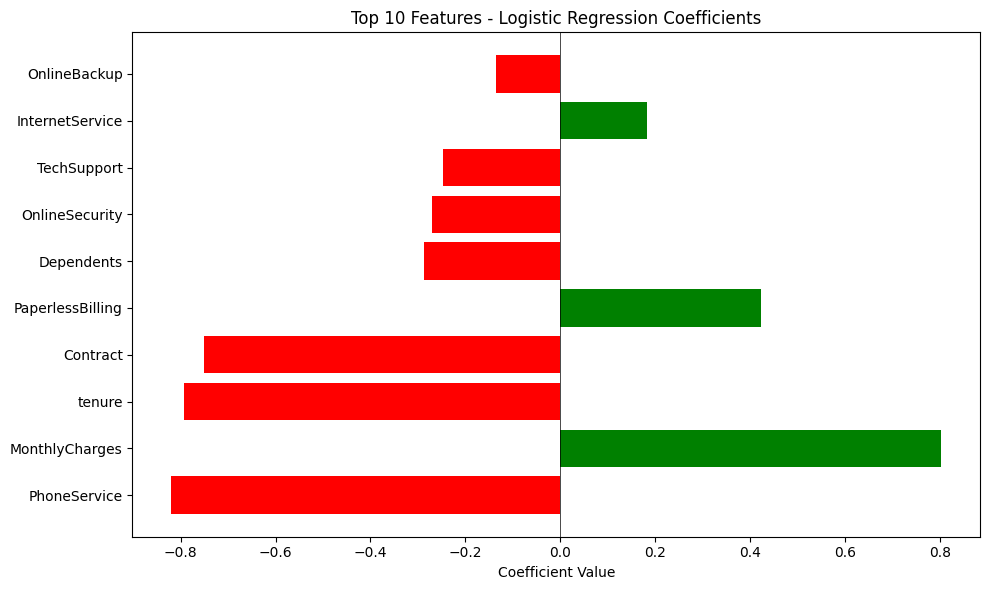


✅ Feature Interpretation:
   Green (positive) coefficients: Increase churn probability
   Red (negative) coefficients: Decrease churn probability


In [6]:
# ================================
# Feature Importance Analysis
# ================================

import numpy as np
import matplotlib.pyplot as plt

# Get feature names
feature_names = X_test.columns.tolist()

# Get coefficients
coefficients = tuned_model.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

# Display top features
print("Top 10 Most Important Features (by coefficient magnitude):")
print(coef_df[['Feature', 'Coefficient']].head(10).to_string(index=False))

# Visualize top features
top_features = coef_df.head(10)

plt.figure(figsize=(10, 6))

colors = [
    'green' if x > 0 else 'red'
    for x in top_features['Coefficient']
]

plt.barh(
    top_features['Feature'],
    top_features['Coefficient'],
    color=colors
)

plt.xlabel('Coefficient Value')
plt.title('Top 10 Features - Logistic Regression Coefficients')

plt.axvline(
    x=0,
    color='black',
    linestyle='-',
    linewidth=0.5
)

plt.tight_layout()
plt.show()

# Interpretation
print("\n✅ Feature Interpretation:")
print("   Green (positive) coefficients: Increase churn probability")
print("   Red (negative) coefficients: Decrease churn probability")

In [9]:

# Final Summary

print("LOGISTIC REGRESSION TUNING")

# Baseline metrics
print("\nBaseline Model (Step 5):")
print("  - Validation ROC AUC: 0.8431")
print("  - Validation Accuracy: 0.8030")

# Extract tuned results
baseline_row = tuning_comparison[
    tuning_comparison['Metric'] == 'ROC AUC'
]

tuned_auc = baseline_row['Tuned'].values[0]
improvement = baseline_row['Improvement'].values[0]

# Tuned model results
print("\nTuned Model (Step 6):")
print(f"  - Validation ROC AUC: {tuned_auc:.4f}")
print(f"  - Improvement: {improvement:+.4f}")

# Test performance
print("\nTest Set Performance:")
print(f"  - ROC AUC: {test_auc:.4f}")
print(f"  - Accuracy: {test_accuracy:.4f}")

# Final verdict
if improvement > 0:
    print("\n✅ Tuning was successful!")
else:
    print("\n⚠️ Baseline model was already strong")

LOGISTIC REGRESSION TUNING

Baseline Model (Step 5):
  - Validation ROC AUC: 0.8431
  - Validation Accuracy: 0.8030

Tuned Model (Step 6):
  - Validation ROC AUC: 0.8431
  - Improvement: -0.0000

Test Set Performance:
  - ROC AUC: 0.8411
  - Accuracy: 0.8023

⚠️ Baseline model was already strong
